In [ ]:
import pandas as pd
import geopandas as gpd
import rioxarray
import numpy as np
import os
import gc
import logging
from pathlib import Path

# Custom script imports (assuming these are in your local directory)
from scripts import clip_raster_safely, aggregate_imp_matrix

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(), logging.FileHandler("processing_log.txt")]
)

class NightLightsProcessor:
    def __init__(self, 
                 states_shp_path, 
                 viirs_path, 
                 nlcd_imp_path, 
                 output_dir="data/processed_states"):
        
        self.viirs_path = Path(viirs_path)
        self.nlcd_imp_path = Path(nlcd_imp_path)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        logging.info("Loading US States Shapefile (cached for all iterations)...")
        self.states_gdf = gpd.read_file(states_shp_path)
        
        # Pre-fetch CRS from rasters to avoid opening them repeatedly just to check CRS
        with rioxarray.open_rasterio(self.viirs_path) as src:
            self.viirs_crs = src.rio.crs
        
        with rioxarray.open_rasterio(self.nlcd_imp_path) as src:
            self.nlcd_crs = src.rio.crs

    def get_state_roi(self, state_name):
        """Extracts the state geometry and projects it to the relevant CRSes."""
        # Get geometry in base CRS
        state_geom = self.states_gdf[self.states_gdf['NAME'] == state_name]
        
        if state_geom.empty:
            raise ValueError(f"State '{state_name}' not found in shapefile.")
            
        # Prepare two versions: one for VIIRS clipping, one for NLCD clipping
        roi_viirs = state_geom.to_crs(self.viirs_crs)
        roi_nlcd = state_geom.to_crs(self.nlcd_crs)
        
        return roi_viirs, roi_nlcd

    def process_state(self, state_name):
        """Main workflow for a single state."""
        logging.info(f"[{state_name}] Starting processing...")
        output_path = self.output_dir / f"{state_name.replace(' ', '_')}_imperv_rad_data.csv"
        
        if output_path.exists():
            logging.info(f"[{state_name}] Output already exists. Skipping.")
            return

        try:
            # 1. Prepare Geometries
            roi_viirs, roi_nlcd = self.get_state_roi(state_name)

            # 2. Process NLCD (High Res)
            logging.info(f"[{state_name}] Clipping NLCD...")
            impervious_ds = clip_raster_safely(self.nlcd_imp_path, roi_nlcd)
            
            if impervious_ds is None:
                raise ValueError("NLCD Clip returned No Data.")

            # Clean NLCD: 250 is the fill value for background/water in NLCD
            impervious_ds = impervious_ds.where(impervious_ds != 250)
            impervious_ds = impervious_ds.astype("float32")

            # 3. Process VIIRS (Low Res)
            logging.info(f"[{state_name}] Clipping VIIRS...")
            viirs_ds = clip_raster_safely(self.viirs_path, roi_viirs)
            
            if viirs_ds is None:
                raise ValueError("VIIRS Clip returned No Data.")
            
            # Remove fill values if present
            if "_FillValue" in viirs_ds.attrs:
                del viirs_ds.attrs["_FillValue"]

            # 4. Aggregation (Resample NLCD mean to VIIRS Grid)
            logging.info(f"[{state_name}] Aggregating/Resampling...")
            
            # NOTE: Assuming aggregate_imp_matrix handles reprojecting impervious_ds to viirs_ds bounds
            # If your script requires them to be in the same CRS first, ensure aggregate_imp_matrix handles that
            # or add reproject_match here.
            aggregated_ds = aggregate_imp_matrix(impervious_ds, viirs_ds, thresholds=None)
            
            # Mask areas where VIIRS itself is NaN (e.g., ocean)
            aggregated_ds = aggregated_ds.where(~np.isnan(viirs_ds))

            # 5. Build DataFrame
            logging.info(f"[{state_name}] Building DataFrame...")
            df = pd.DataFrame()
            
            # Flatten arrays
            # Ensure we are extracting the exact same pixels from both
            df['mean_impervious'] = aggregated_ds['mean'].values.ravel()
            df['viirs_radiance'] = viirs_ds.values.ravel()
            
            # Drop NaNs (water, out of bounds)
            df = df.dropna()
            
            # 6. Save
            df.to_csv(output_path, index=False)
            logging.info(f"[{state_name}] Success. Saved {len(df)} rows.")

        except Exception as e:
            logging.error(f"[{state_name}] FAILED: {str(e)}")
        
        finally:
            # Clean up memory for the next loop (Crucial for large rasters)
            del roi_viirs, roi_nlcd
            if 'impervious_ds' in locals(): del impervious_ds
            if 'viirs_ds' in locals(): del viirs_ds
            if 'aggregated_ds' in locals(): del aggregated_ds
            gc.collect()

# =============================================================================
# RUNNER
# =============================================================================
if __name__ == "__main__":
    
    # --- CONFIG ---
    PATHS = {
        "states_shp": "data/tl_2024_us_state/tl_2024_us_state.shp",
        "viirs": "data/SVDNB_npp_20211101-20211130_75N180W_vcmcfg_v10_c202112060900/SVDNB_npp_20211101-20211130_75N180W_vcmcfg_v10_c202112060900.avg_rade9h.tif",
        "nlcd": "data/Annual_NLCD_FctImp_2021_CU_C1V0/Annual_NLCD_FctImp_2021_CU_C1V0.tif",
        "output": "data/processed_states"
    }
    
    # Define which states you want to run
    TARGET_STATES = ['North Carolina', 'Virginia', 'South Carolina', 'Georgia']
    
    # Initialize the processor (Loads Shapefile once)
    processor = NightLightsProcessor(
        states_shp_path=PATHS["states_shp"],
        viirs_path=PATHS["viirs"],
        nlcd_imp_path=PATHS["nlcd"],
        output_dir=PATHS["output"]
    )
    
    # Run the loop
    for state in TARGET_STATES:
        processor.process_state(state)
        
    print("Batch processing complete.")

Processing data for North Carolina...
Step 1: Preparing and clipping high-resolution NLCD data...


In [4]:
df_sample = pd.DataFrame()
df_sample['mean'] = aggregated_ds['mean'].values.ravel()

df_sample["viirs"] = viirs_ds.values.ravel()


df_sample = df_sample.dropna()
#rename mean to mean_impervious
df_sample = df_sample.rename(columns={"mean": "mean_impervious"})
df_sample = df_sample.rename(columns={"viirs": "viirs_radiance"})
df_sample.to_csv("data/NC_sample_imperv_rad_data.csv", index=False)

,mean_impervious,viirs_radiance
2776,0.0,0.46
2777,0.0,0.39
2778,0.0,0.39
2779,0.0,0.34
2780,0.0,0.37


In [2]:
print(np.nanmean(aggregated_ds['mean'].values))
print(np.nanmean(aggregated_ds['max'].values))
print(np.nanmean(aggregated_ds['rms'].values))

16.090391
54.07635
21.608843


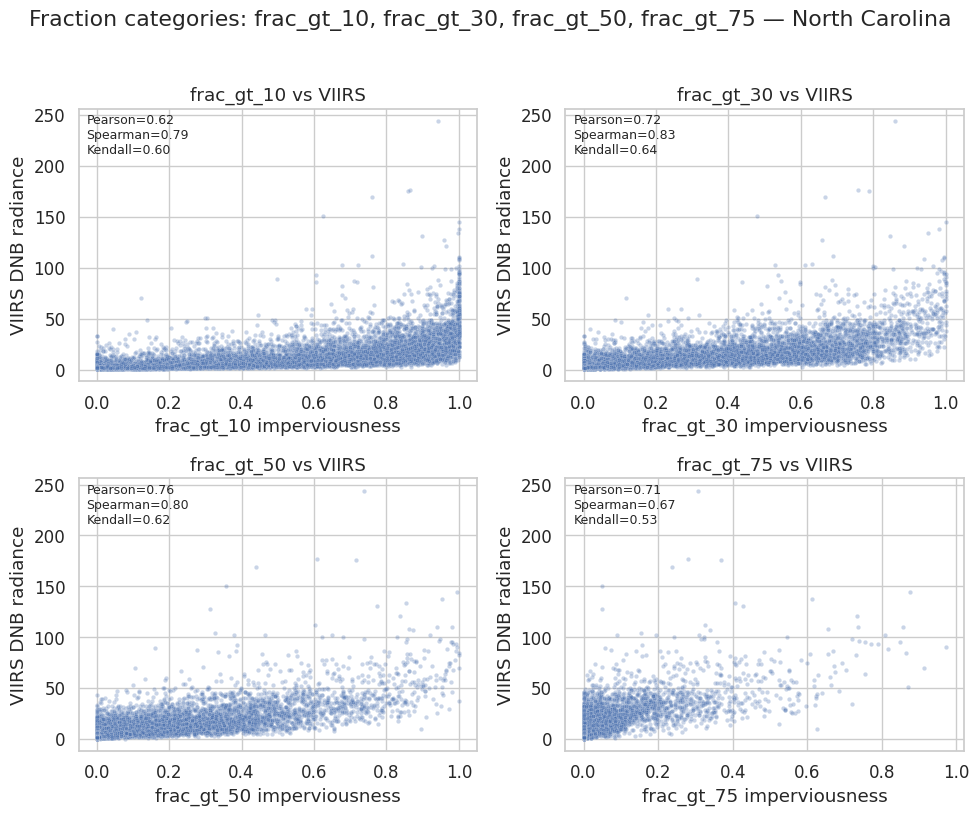

In [3]:
df = pd.DataFrame()
for var in aggregated_ds.data_vars:
    df[var] = aggregated_ds[var].values.ravel()

df["viirs"] = viirs_ds.values.ravel()

# Remove NaNs
df = df.dropna()
df['state'] = STATE_TO_PROCESS

sns.set(style="whitegrid", context="notebook", font_scale=1.1)

# Separate variables into stats (mean, rms, max) and fraction categories (frac_*)
all_vars = list(aggregated_ds.data_vars)
stats_vars = [v for v in all_vars if v in ( )]
frac_vars = [v for v in all_vars if v.startswith("frac_")]

from scipy.stats import pearsonr, spearmanr, kendalltau

# --- Plot stats group in one figure ---
if stats_vars:
    import math
    n = len(stats_vars)
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes_flat = axes.flatten()
    for i, var in enumerate(stats_vars):
        ax = axes_flat[i]
        x = df[var].values
        y = df['viirs'].values
        sns.scatterplot(x=x, y=y, alpha=0.3, s=10, ax=ax)

        # compute correlations on finite data
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 3:
            try:
                pr, _ = pearsonr(x[mask], y[mask])
            except Exception:
                pr = np.nan
            try:
                sr, _ = spearmanr(x[mask], y[mask])
            except Exception:
                sr = np.nan
            try:
                kt, _ = kendalltau(x[mask], y[mask])
            except Exception:
                kt = np.nan
        else:
            pr = sr = kt = np.nan

        # Title and annotation
        ax.set_title(f"{var} vs VIIRS")
        ax.set_xlabel(f"{var} imperviousness")
        ax.set_ylabel("VIIRS DNB radiance")
        ann = f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nKendall={kt:.2f}"
        ax.text(0.02, 0.98, ann, transform=ax.transAxes, fontsize=9, va='top')

    for ax in axes_flat[n:]:
        ax.axis('off')
    plt.suptitle(f"Stats: {', '.join(stats_vars)} — {STATE_TO_PROCESS}", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Plot fraction group in one figure ---
if frac_vars:
    import math
    n = len(frac_vars)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes_flat = axes.flatten()
    for i, var in enumerate(frac_vars):
        ax = axes_flat[i]
        x = df[var].values
        y = df['viirs'].values
        sns.scatterplot(x=x, y=y, alpha=0.3, s=10, ax=ax)

        # compute correlations on finite data
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 3:
            try:
                pr, _ = pearsonr(x[mask], y[mask])
            except Exception:
                pr = np.nan
            try:
                sr, _ = spearmanr(x[mask], y[mask])
            except Exception:
                sr = np.nan
            try:
                kt, _ = kendalltau(x[mask], y[mask])
            except Exception:
                kt = np.nan
        else:
            pr = sr = kt = np.nan

        ax.set_title(f"{var} vs VIIRS")
        ax.set_xlabel(f"{var} imperviousness")
        ax.set_ylabel("VIIRS DNB radiance")
        ann = f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nKendall={kt:.2f}"
        ax.text(0.02, 0.98, ann, transform=ax.transAxes, fontsize=9, va='top')

    for ax in axes_flat[n:]:
        ax.axis('off')
    plt.suptitle(f"Fraction categories: {', '.join(frac_vars)} — {STATE_TO_PROCESS}", y=1.02)
    plt.tight_layout()
    plt.show()


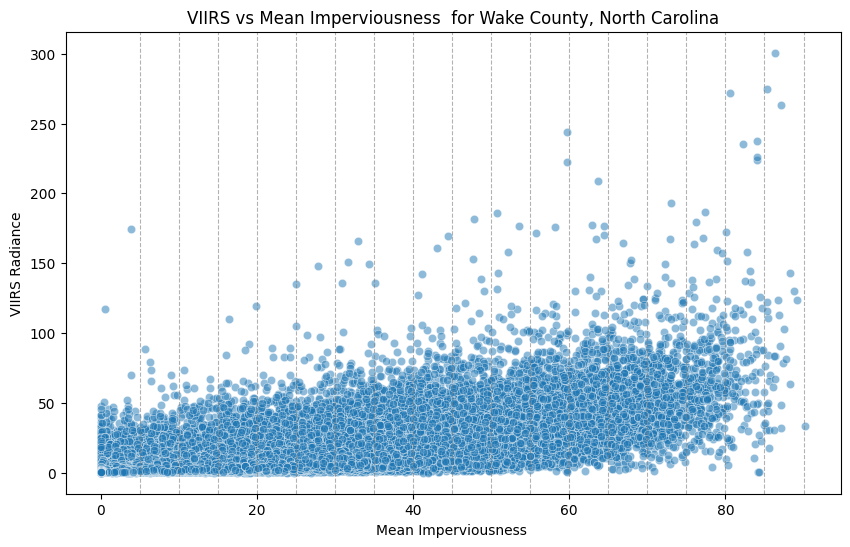

In [5]:
#Plot mean vs viirs
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='mean_impervious', y='viirs_radiance', alpha=0.5)
plt.title(f'VIIRS vs Mean Imperviousness  for Wake County, North Carolina')
plt.ylabel('VIIRS Radiance')
plt.xlabel(f'Mean Imperviousness ')
plt.grid(False)

# Add vertical lines at 5, 10, ..., 95 to separate 0-5,5-10,...,95-100 bins
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
for b in range(5, 100, 5):
    if xmin <= b <= xmax:
        ax.vlines(b, ymin=ymin, ymax=ymax, color='gray', alpha=0.6, linewidth=0.8, linestyle='--')

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

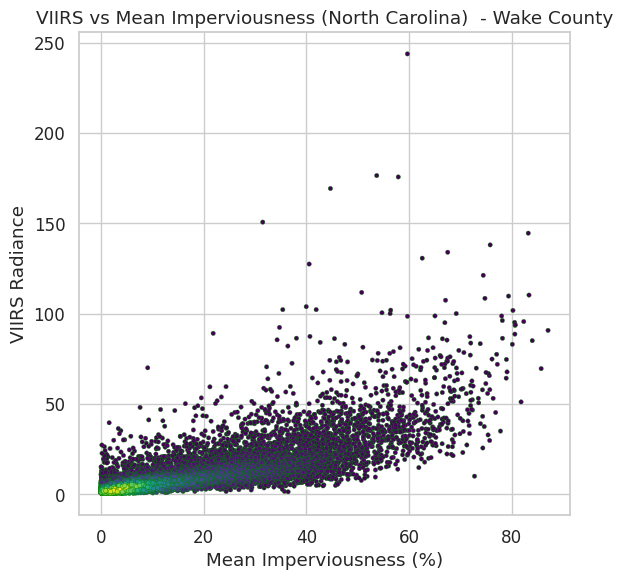

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Density-colored scatter: mean imperviousness vs VIIRS radiance
# Uses the flattened/cleaned dataframe `df` (ensure df exists from previous cells)
values = np.vstack([df["mean"].values, df["viirs"].values]) #drop where values of mean are 0
values = values[:, values[0] != 0]  # Keep only non-zero mean values

kernel = stats.gaussian_kde(values)(values)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=values[0], y=values[1], c=kernel, cmap="viridis", ax=ax, s=10, edgecolor='green')
ax.set_xlabel('Mean Imperviousness (%)')
ax.set_ylabel('VIIRS Radiance')
ax.set_title(f'VIIRS vs Mean Imperviousness ({STATE_TO_PROCESS}) {" - Wake County" if USE_COUNTY_MASK else ""}')
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def compare_states(df, state_col="state", imperv_col="mean", viirs_col="viirs",
                   bins=np.arange(0, 101, 5)):
    """
    Compare conditional distributions of VIIRS radiance given imperviousness,
    between states.

    Parameters
    ----------
    df : DataFrame
        Must contain columns [state_col, imperv_col, viirs_col].
    state_col : str
        Column name for state labels.
    imperv_col : str
        Column name for mean imperviousness.
    viirs_col : str
        Column name for VIIRS radiance.
    bins : array-like
        Bin edges for imperviousness.

    Returns
    -------
    results : dict
        Dictionary of KS test results for each bin.
    """

    # assign imperviousness bins
    df = df.copy()
    df["bin"] = pd.cut(df[imperv_col], bins=bins, include_lowest=True)

    states = df[state_col].unique()
    if len(states) != 2:
        raise ValueError("This demo only compares exactly two states.")

    state_a, state_b = states
    results = {}

    # loop over bins
    for b in df["bin"].cat.categories:
        vals_a = df.loc[(df[state_col] == state_a) & (df["bin"] == b), viirs_col]
        vals_b = df.loc[(df[state_col] == state_b) & (df["bin"] == b), viirs_col]

        if len(vals_a) > 10 and len(vals_b) > 10:  # need enough samples
            stat, pval = ks_2samp(vals_a, vals_b)
            results[str(b)] = {"KS": stat, "p": pval, "n_a": len(vals_a), "n_b": len(vals_b)}

    # visualization: bin means + error bars
    plt.figure(figsize=(10, 6))
    sns.pointplot(data=df, x="bin", y=viirs_col, hue=state_col,
                  estimator=np.mean, errorbar=("pi", 95), dodge=True)
    plt.xticks(rotation=45)
    plt.ylabel("Mean VIIRS radiance")
    plt.xlabel("Imperviousness bin (%)")
    plt.title("Conditional VIIRS radiance by imperviousness and state")
    plt.legend(title="State")
    plt.tight_layout()
    plt.show()

    return results


# ---- Example usage ----
# df should look like:
# state | impervious | viirs
#  NY   |    34.2    |  56.1
#  CA   |    12.7    |  18.4
# etc.
# results = compare_states(df)

# print results for statistical comparison
# for bin_label, stats in results.items():
#     print(bin_label, stats)


In [40]:
#summarize df_final states
df_final["state"].value_counts()

state
Utah              1323069
North Carolina     797848
Name: count, dtype: int64

AttributeError: 'numpy.ndarray' object has no attribute 'dropna'

## ALl States

In [ ]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd
def sample_state_data():


def summarize_by_impervious_bins(df, state_name, variable="mean", n_bins=20):
    """
    Summarize VIIRS brightness (response) by imperviousness bins (predictor).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns 'viirs' and the imperviousness variable (e.g. 'mean').
    state_name : str
        State name for labeling output.
    variable : str, default 'mean'
        Imperviousness variable name to bin by.
    n_bins : int, default 20
        Number of bins (equal-width bins from 0–100, not percentiles).
    """
    # Drop missing or invalid data
    df = df[["viirs", variable]].dropna()

    # Define bin edges and labels (e.g. 0–5, 5–10, …)
    bin_edges = np.linspace(0, 100, n_bins + 1)
    bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(n_bins)]

    # Clip out-of-range imperviousness (some NLCD pixels can be >100 due to rounding)
    df = df[(df[variable] >= 0) & (df[variable] <= 100)]

    # Bin by imperviousness
    df["imp_bin"] = pd.cut(df[variable], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # Aggregate VIIRS brightness by bin
    summary = (
        df.groupby("imp_bin")["viirs"]
          .agg(["count", "mean", "std", "min", "max"])
          .reset_index()
    )

    # Add metadata
    summary["state"] = state_name
    summary["predictor"] = variable

    return summary


In [ ]:
sns.set(style="whitegrid", context="notebook", font_scale=1.1)

from scipy.stats import pearsonr, spearmanr, kendalltau

# Separate variables into stats (mean, rms, max) and fraction categories (frac_*) for no-roads
all_no_roads = list(aggregated_ds_no_roads.data_vars)
stats_no_roads = [v for v in all_no_roads if v in ("mean", "rms", "max")]
frac_no_roads = [v for v in all_no_roads if v.startswith("frac_")]

# --- Plot stats (no-roads) ---
if stats_no_roads:
    import math
    n = len(stats_no_roads)
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes_flat = axes.flatten()
    for i, var in enumerate(stats_no_roads):
        ax = axes_flat[i]
        x = df_no_roads[var].values
        y = df_no_roads['viirs'].values
        sns.scatterplot(x=x, y=y, alpha=0.3, s=10, ax=ax)

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 3:
            try:
                pr, _ = pearsonr(x[mask], y[mask])
            except Exception:
                pr = np.nan
            try:
                sr, _ = spearmanr(x[mask], y[mask])
            except Exception:
                sr = np.nan
            try:
                kt, _ = kendalltau(x[mask], y[mask])
            except Exception:
                kt = np.nan
        else:
            pr = sr = kt = np.nan

        ax.set_title(f"{var} vs VIIRS no roads")
        ax.set_xlabel(var)
        ax.set_ylabel("VIIRS DNB radiance")
        ann = f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nKendall={kt:.2f}"
        ax.text(0.02, 0.98, ann, transform=ax.transAxes, fontsize=9, va='top')

    for ax in axes_flat[n:]:
        ax.axis('off')
    plt.suptitle("Stats (no roads)", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Plot fractions (no-roads) ---
if frac_no_roads:
    import math
    n = len(frac_no_roads)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes_flat = axes.flatten()
    for i, var in enumerate(frac_no_roads):
        ax = axes_flat[i]
        x = df_no_roads[var].values
        y = df_no_roads['viirs'].values
        sns.scatterplot(x=x, y=y, alpha=0.3, s=10, ax=ax)

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 3:
            try:
                pr, _ = pearsonr(x[mask], y[mask])
            except Exception:
                pr = np.nan
            try:
                sr, _ = spearmanr(x[mask], y[mask])
            except Exception:
                sr = np.nan
            try:
                kt, _ = kendalltau(x[mask], y[mask])
            except Exception:
                kt = np.nan
        else:
            pr = sr = kt = np.nan

        ax.set_title(f"{var} vs VIIRS no roads")
        ax.set_xlabel(var)
        ax.set_ylabel("VIIRS DNB radiance")
        ann = f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nKendall={kt:.2f}"
        ax.text(0.02, 0.98, ann, transform=ax.transAxes, fontsize=9, va='top')

    for ax in axes_flat[n:]:
        ax.axis('off')
    plt.suptitle("Fraction categories (no roads)", y=1.02)
    plt.tight_layout()
    plt.show()

In [4]:
import os
import pandas as pd
import geopandas as gpd
import rioxarray
import numpy as np
from rasterio.enums import Resampling
from scripts import clip_raster_safely, aggregate_imp_matrix
from scripts import summarize_by_impervious_bins  # import the earlier function

# =============================================================================
# 1. SETUP
# =============================================================================
TIGER_SHAPEFILE = "data/tl_2024_us_state/tl_2024_us_state.shp"
TIGER_COUNTY_SHAPEFILE = "data/tl_2024_us_county/tl_2024_us_county.shp"
VIIRS_RASTER = "data/SVDNB_npp_20211101-20211130_75N180W_vcmcfg_v10_c202112060900/SVDNB_npp_20211101-20211130_75N180W_vcmcfg_v10_c202112060900.avg_rade9h.tif"
NLCD_IMPERVIOUS_RASTER = "data/Annual_NLCD_FctImp_2021_CU_C1V0/Annual_NLCD_FctImp_2021_CU_C1V0.tif"
NLCD_DESCRIPTOR_RASTER = "data/Annual_NLCD_ImpDsc_2021_CU_C1V0/Annual_NLCD_ImpDsc_2021_CU_C1V0.tif"

OUTPUT_DIR = "outputs/state_summaries"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load reference rasters once ---
viirs_template = rioxarray.open_rasterio(VIIRS_RASTER, chunks='auto')
viirs_crs = viirs_template.rio.crs

# --- Load state boundaries ---
states_gdf = gpd.read_file(TIGER_SHAPEFILE).to_crs(viirs_crs)

#filter to CONUS
states_gdf = states_gdf[~states_gdf['STUSPS'].isin(['AK', 'HI', 'PR', 'VI', 'GU', 'MP', 'AS'])].reset_index(drop=True)
# --- Load NLCD CRS ---
with rioxarray.open_rasterio(NLCD_IMPERVIOUS_RASTER, masked=True) as src:
    if "_FillValue" in src.attrs:
        del src.attrs["_FillValue"]
    nlcd_crs = src.rio.crs


# =============================================================================
# 2. LOOP OVER STATES
# =============================================================================
state_summaries = []

for idx, row in states_gdf.iterrows():
    state_name = row["NAME"]
    print(f"\n=== Processing {state_name} ===")

    try:
        # --- Define ROI for this state ---
        roi_viirs = gpd.GeoDataFrame([row], crs=viirs_crs)
        roi_nlcd = roi_viirs.to_crs(nlcd_crs)

        # --- Clip NLCD rasters ---
        impervious_ds = clip_raster_safely(NLCD_IMPERVIOUS_RASTER, roi_nlcd)
        descriptor_ds = clip_raster_safely(NLCD_DESCRIPTOR_RASTER, roi_nlcd)
        if impervious_ds is None or descriptor_ds is None:
            print(f"Skipping {state_name}: No data after clipping.")
            continue

        # Clean up fill values
        for ds in [impervious_ds, descriptor_ds]:
            if "_FillValue" in ds.attrs:
                del ds.attrs["_FillValue"]
        impervious_ds = impervious_ds.where(impervious_ds != 250)
        descriptor_ds = descriptor_ds.where(descriptor_ds != 250)

        # Mask out roads (descriptor == 1)
        impervious_no_roads = impervious_ds.where(descriptor_ds != 1)

        # --- Clip VIIRS ---
        viirs_ds = clip_raster_safely(VIIRS_RASTER, roi_viirs)
        for ds in [viirs_ds]:
            if "_FillValue" in ds.attrs:
                del ds.attrs["_FillValue"]

        # --- Aggregate NLCD to VIIRS resolution ---
        impervious_ds = impervious_ds.astype("float32")
        aggregated_ds = aggregate_imp_matrix(impervious_ds, viirs_ds, thresholds=(10, 30, 50, 75))
        aggregated_ds = aggregated_ds.where(~np.isnan(viirs_ds))

        # --- Combine with VIIRS ---
        df_state = aggregated_ds.to_dataframe().reset_index()
        df_state["viirs"] = viirs_ds.values.flatten()
        df_state = df_state.dropna(subset=["mean", "viirs"])

        # --- Summarize by imperviousness bins ---
        summary_df = summarize_by_impervious_bins(df_state, state_name, variable="mean", n_bins=20)
        state_summaries.append(summary_df)

        # --- Save per-state CSV ---
        out_path = os.path.join(OUTPUT_DIR, f"{state_name.replace(' ', '_')}_summary.csv")
        summary_df.to_csv(out_path, index=False)
        print(f"Saved summary for {state_name} → {out_path}")

    except Exception as e:
        print(f"❌ Error processing {state_name}: {e}")
        continue


# =============================================================================
# 3. COMBINE SUMMARIES (OPTIONAL)
# =============================================================================
summary_all = pd.concat(state_summaries, ignore_index=True)
summary_all.to_csv(os.path.join(OUTPUT_DIR, "national_viirs_impervious_summary.csv"), index=False)

print("\n✅ Completed all states.")



=== Processing West Virginia ===


/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]


Saved summary for West Virginia → outputs/state_summaries/West_Virginia_summary.csv

=== Processing Florida ===


/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]


Saved summary for Florida → outputs/state_summaries/Florida_summary.csv

=== Processing Illinois ===


...

/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]
/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]


Saved summary for Virginia → outputs/state_summaries/Virginia_summary.csv

=== Processing District of Columbia ===
Saved summary for District of Columbia → outputs/state_summaries/District_of_Columbia_summary.csv

=== Processing Iowa ===


/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]


Saved summary for Iowa → outputs/state_summaries/Iowa_summary.csv

=== Processing Arizona ===
Saved summary for Arizona → outputs/state_summaries/Arizona_summary.csv

✅ Completed all states.


/home/tworm/Documents/nightlights/scripts.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("imp_bin")["viirs"]


In [13]:
import pandas as pd
import numpy as np
from itertools import combinations

def find_most_different_states(summary_all, metric="rmse"):
    """
    Identify the two states whose VIIRS–imperviousness curves differ most.
    
    Parameters
    ----------
    summary_all : pd.DataFrame
        Combined output of summarize_by_impervious_bins across all states.
    metric : str, "rmse" or "mae"
        Metric to quantify difference between mean VIIRS brightness curves.
    """
    # Pivot to get mean brightness per bin for each state
    pivot = summary_all.pivot(index="imp_bin", columns="state", values="mean").dropna(how="any")

    diffs = []
    for s1, s2 in combinations(pivot.columns, 2):
        if metric == "rmse":
            diff = np.sqrt(np.nanmean((pivot[s1] - pivot[s2])**2))
        else:
            diff = np.nanmean(np.abs(pivot[s1] - pivot[s2]))
        diffs.append((s1, s2, diff))

    diffs_df = pd.DataFrame(diffs, columns=["state1", "state2", "difference"])
    diffs_df = diffs_df.sort_values("difference", ascending=False).reset_index(drop=True)
    return diffs_df


In [12]:
diffs_df = find_most_different_states(summary_all)
top_pair = diffs_df.iloc[0]
print(top_pair)
# → e.g. Texas vs. Vermont: RMSE = 0.41

#remove District of Columbia from diffs_df and print again
diffs_df = diffs_df[~diffs_df['state1'].isin(['District of Columbia']) & ~diffs_df['state2'].isin(['District of Columbia'])].reset_index(drop=True)
top_pair = diffs_df.iloc[0]
print(top_pair)

#print the brightest 5 states
print(diffs_df.head(5))

state1        District of Columbia
state2                      Oregon
difference               84.459846
Name: 0, dtype: object
state1           Nevada
state2           Oregon
difference    52.276669
Name: 0, dtype: object
      state1      state2  difference
0     Nevada      Oregon   52.276669
1     Nevada     Vermont   51.601040
2      Maine      Nevada   46.982536
3     Nevada  Washington   46.015274
4  Louisiana      Oregon   45.951511


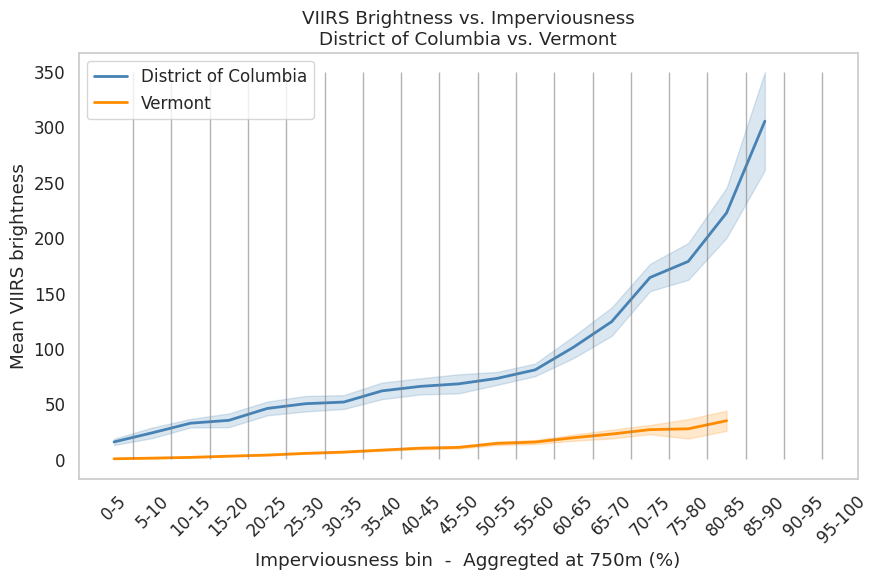

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_state_comparison(summary_all, state1, state2):
    """
    Plot VIIRS brightness vs imperviousness for two states, with 95% CI.
    """
    df1 = summary_all[summary_all["state"] == state1].copy()
    df2 = summary_all[summary_all["state"] == state2].copy()

    # Compute CI for both states
    for df in [df1, df2]:
        df["se"] = df["std"] / np.sqrt(df["count"])
        df["ci_upper"] = df["mean"] + 1.96 * df["se"]
        df["ci_lower"] = df["mean"] - 1.96 * df["se"]

    plt.figure(figsize=(9, 6))
    sns.lineplot(df1, x="imp_bin", y="mean", label=state1, color="steelblue", linewidth=2)
    sns.lineplot(df2, x="imp_bin", y="mean", label=state2, color="darkorange", linewidth=2)

    # Add shaded confidence intervals
    plt.fill_between(df1["imp_bin"], df1["ci_lower"], df1["ci_upper"], color="steelblue", alpha=0.2)
    plt.fill_between(df2["imp_bin"], df2["ci_lower"], df2["ci_upper"], color="darkorange", alpha=0.2)

    # Add vertical bin divider lines (between categorical ticks)
    n_bins = len(df1["imp_bin"])
    if n_bins > 1:
        ymax = max(df1["ci_upper"].max(), df2["ci_upper"].max())
        # boundaries between ticks at 0.5, 1.5, ..., n-1.5
        boundaries = np.arange(0.5, n_bins - 0.5, 1.0)
        plt.vlines(boundaries, ymin=0, ymax=ymax, color="gray", alpha=0.6, linewidth=1)

    plt.xticks(rotation=45)
    plt.xlabel("Imperviousness bin  -  Aggregted at 750m (%)")
    plt.ylabel("Mean VIIRS brightness")
    plt.title(f"VIIRS Brightness vs. Imperviousness\n{state1} vs. {state2}")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_state_comparison(summary_all, 'District of Columbia', 'Vermont')

In [ ]:

# =============================================================================
# 3. RESAMPLE NLCD TO MATCH THE VIIRS GRID
# =============================================================================
print("Step 2: Resampling NLCD data to match the VIIRS grid...")

# --- Open and clip the VIIRS raster to use as our template grid ---
viirs_template = rioxarray.open_rasterio(VIIRS_RASTER).rio.clip(roi_reprojected.geometry)

# --- Resample the NLCD impervious data ---
# This resamples the NLCD data to the exact grid (CRS, resolution, bounds) of the
# VIIRS template. The 'average' method calculates the mean of all high-res
# NLCD pixels that fall within each low-res VIIRS pixel.
impervious_resampled = impervious_no_roads.rio.reproject_match(
    viirs_template,
    resampling=Resampling.average
)

# --- Resample the binary highly-impervious layer ---
# Taking the 'average' of a 0/1 raster gives the fraction of '1's,
# which is exactly what we need.
fraction_resampled = highly_impervious.rio.reproject_match(
    viirs_template,
    resampling=Resampling.average
)

# =============================================================================
# 4. COMBINE DATA AND EXPORT TO CSV
# =============================================================================
print(f"Step 3: Combining data and exporting to {OUTPUT_CSV_FILE}...")

# --- Extract the raw data arrays ---
# At this point, all three arrays are perfectly aligned.
viirs_vals = viirs_template.to_numpy().flatten()
impervious_vals = impervious_resampled.to_numpy().flatten()
fraction_vals = fraction_resampled.to_numpy().flatten()

# --- Create a Pandas DataFrame ---
df = pd.DataFrame({
    'viirs_avg_rad': viirs_vals,
    'mean_impervious': impervious_vals,
    'fraction_highly_impervious': fraction_vals
})

# --- Clean up and save ---
# Drop rows where the VIIRS pixel had no value (often the black border of the raster)
# and where calculations resulted in NaN.
df_clean = df.dropna(subset=['viirs_avg_rad'])
df_clean = df_clean[df_clean['viirs_avg_rad'] > 0]

df_clean.to_csv(OUTPUT_CSV_FILE, index=False)

print("Processing complete!")
print(df_clean.head())